# 27. Composite distributions

<div class="callout callout-note">
Language: <strong>Python</strong> (Jupyter) - <a href="r.qmd">R version</a>
</div>

Most of the distribution surface takes a family name and a parameter vector. Five families do
not, because they are built out of other distributions or out of the data itself: a truncated
distribution, a mixture, a competing-risks system, an empirical curve, and a kernel density.
`corehydropy` calls them composite, and each has its own constructor: `dist_truncated()`,
`dist_mixture()`, `dist_competing_risks()`, `dist_empirical()`, and `dist_kde()`. What comes back
is an ordinary `Distribution`: the density, distribution, quantile, random-draw, moment,
parameter, and log-likelihood methods all take one.

This example uses three of them on one record: a mixture for a basin with two flood-generating
mechanisms, a kernel density as a nonparametric reference, and a truncated distribution for a
physical lower bound.

## What you'll learn

- Fit a two-component mixture with `model_mixture()` and `fit_mle()`, then rebuild the fit as a
  standalone `dist_mixture()` distribution.
- See where a second component changes the frequency curve, and where it does not.
- Build a kernel density, reproduce its default bandwidth, and understand what
  `bounded_by_data` does and does not restrict.
- Renormalize a distribution onto a physical range with `dist_truncated()`.
- Know the two things composites cannot do.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import corehydropy as ch

## A mixed-population record

Sixty annual peak flows from a basin with two flood seasons: spring snowmelt produces a cluster
of moderate peaks, and summer convective storms produce a smaller number of much larger ones. The
record is written out here so the page is self-contained and both languages read the same
numbers.

In [2]:
peaks = [
    1240, 8720, 2110, 1240, 11180, 1570, 11620, 4470, 6470, 1960,
    1740, 3530, 7440, 9080, 1500, 5760, 7920, 2480, 1790, 2650,
    1740, 1590, 2080, 2220, 1800, 2120, 11430, 8710, 19870, 1570,
    1540, 5290, 1480, 7750, 1900, 5630, 1910, 20340, 1280, 9270,
    5720, 1390, 14490, 2180, 1590, 1530, 6540, 2470, 2490, 7780,
    13010, 2140, 1220, 11790, 2820, 2000, 2390, 1440, 8740, 2470,
]
n = len(peaks)
print(f"n = {n}, range {min(peaks):,} to {max(peaks):,} cfs")

n = 60, range 1,220 to 20,340 cfs


## One distribution, or two?

`model_mixture()` builds a weighted mixture model, and `fit_mle()` fits it the same way it fits
any other model. The single-family fit is the comparison.

In [3]:
single_fit = ch.fit_mle(ch.model_univariate("LogNormal", peaks))
mix_fit = ch.fit_mle(ch.model_mixture(["LogNormal", "LogNormal"], peaks))

# `Fit.parameters` is a dict keyed by parameter name, and a mixture labels every parameter of a
# component with that component's tag, so names repeat and the dict silently drops values: six
# fitted numbers collapse to four entries. `standard_errors`, `map`, `posterior_mean` and the
# printed summary lose the same values. Read the ordered vector off the fitted model spec.
p = list(mix_fit.model.spec["parameter_values"])
pd.Series(p, index=mix_fit.parameter_names).round(4)

Weight (w₁)    0.4129
Weight (w₂)    0.5871
D1             3.9323
D1             0.1814
D2             3.2639
D2             0.1046
dtype: float64

The parameter vector is the mixture weights first, then each component's own parameters in order,
which is exactly how the core lays a mixture's parameters out.

In [4]:
components = [ch.Distribution("LogNormal", p[2:4]), ch.Distribution("LogNormal", p[4:6])]

for i, comp in enumerate(components):
    print(f"component {i + 1}: weight {p[i]:.4f}, median {round(comp.quantile(0.5)):,} cfs")

component 1: weight 0.4129, median 8,557 cfs
component 2: weight 0.5871, median 1,836 cfs


Two seasons, recovered from the record alone: a wide component centered near 8,557 cfs carrying
weight 0.4129, and a narrow one centered near 1,836 cfs carrying the rest.

In [5]:
gof = pd.DataFrame(
    {
        "parameters": [len(single_fit.parameter_names), len(mix_fit.parameter_names)],
        "log_likelihood": [single_fit.log_likelihood, mix_fit.log_likelihood],
        "aic": [single_fit.aic, mix_fit.aic],
        "bic": [single_fit.bic, mix_fit.bic],
    },
    index=["LogNormal", "Two-component mixture"],
)
gof.round(3)

,parameters,log_likelihood,aic,bic
LogNormal,2,-562.620,1129.239,1133.428
Two-component mixture,6,-541.624,1095.249,1107.815


The mixture costs four extra parameters, and both criteria still prefer it: its AIC and its BIC
are lower than the single fit's. A single lognormal cannot be both narrow enough for the snowmelt
cluster and wide enough for the storm peaks.

## Rebuilding the fit as a distribution

`fit_mle()` returns a fit, not a distribution. `dist_mixture()` turns the fitted numbers back
into a `Distribution` the other methods accept, and the log-likelihood of that composite over
the same record reproduces the fit's own value exactly.

In [6]:
mixture = ch.dist_mixture(components, weights=p[0:2])
single = ch.Distribution("LogNormal", list(single_fit.parameters.values()))

print(mixture)
print(f"log-likelihood: {mixture.log_likelihood(peaks):.10f} from dist_mixture(), "
      f"{mix_fit.log_likelihood:.10f} from the fit")

Distribution(Mixture (composite): {"family": "Mixture", "components": [{"family": "LogNormal", "parameters": [3...)
log-likelihood: -541.6244186353 from dist_mixture(), -541.6244186353 from the fit


## Where the second component changes the answer

In [7]:
aeps = np.array([0.5, 0.1, 0.01, 0.002])
quantiles = pd.DataFrame(
    {
        "single": [single.quantile(1 - a) for a in aeps],
        "mixture": [mixture.quantile(1 - a) for a in aeps],
    },
    index=[f"{100 * a:g}% AEP" for a in aeps],
)
quantiles["ratio"] = quantiles["mixture"] / quantiles["single"]
quantiles.round(3)

,single,mixture,ratio
50% AEP,3465.790,2359.245,0.681
10% AEP,9974.785,11461.031,1.149
1% AEP,23615.112,19517.846,0.826
0.2% AEP,37228.118,25218.021,0.677


The mixture is not uniformly heavier. It raises the 10% quantile from 9,975 to 11,461 cfs,
because the storm component puts real probability where a single lognormal had a thin shoulder.
It then *lowers* the 1% and 0.2% quantiles, because each component has its own scale and neither
is as diffuse as the single fit forced to straddle both clusters. Splitting a bimodal record into
two components is not the same as making its tail heavier.

In [8]:
pd.DataFrame([single.moments(), mixture.moments()], index=["single", "mixture"]).round(3)

,mean,median,mode,sd,skewness,kurtosis,minimum,maximum
single,4870.273,3465.790,3465.790,4808.281,3.924,39.305,0.0,inf
mixture,4965.313,2359.245,7186.722,4520.883,1.574,5.837,0.0,inf


The moments say the same thing. The two distributions have nearly the same mean, but the
mixture's standard deviation, skewness, and kurtosis are all smaller and its median is far lower.
Read the mixture's reported mode with care: the core finds it by maximizing the density with a
Brent search over the interval between the 0.1% and 99.9% quantiles, which on a two-humped
density converges to whichever hump the search lands in.

## A kernel density as a nonparametric reference

`dist_kde()` builds a density by summing a kernel centered at each observation. With no bandwidth
supplied it uses the rule `h = s * (4 / (3n))**(1/5)`, where `s` is the sample standard
deviation. Passing that value explicitly reproduces the default exactly.

In [9]:
h = float(np.std(peaks, ddof=1) * (4 / (3 * n)) ** 0.2)
kde = ch.dist_kde(peaks)
same = kde.quantile(0.9) == ch.dist_kde(peaks, bandwidth=h).quantile(0.9)
print(f"bandwidth {h:.6f}; explicit bandwidth reproduces the default: {same}")

bandwidth 2143.864822; explicit bandwidth reproduces the default: True


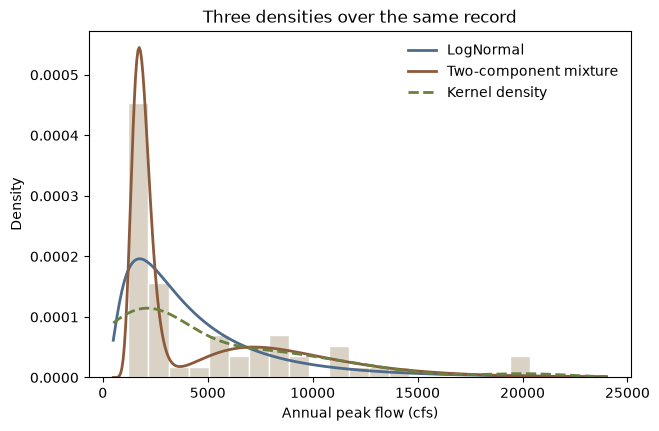

In [10]:
grid = np.linspace(500, 24000, 400)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(peaks, bins=20, density=True, color="#d9d2c5", edgecolor="white")
ax.plot(grid, single.pdf(grid), lw=2, color="#4d6b8a", label="LogNormal")
ax.plot(grid, mixture.pdf(grid), lw=2, color="#8c5a3b", label="Two-component mixture")
ax.plot(grid, kde.pdf(grid), lw=2, ls="--", color="#6b7f3f", label="Kernel density")
ax.set_xlabel("Annual peak flow (cfs)")
ax.set_ylabel("Density")
ax.set_title("Three densities over the same record")
ax.legend(frameon=False)
plt.show()

`bounded_by_data`, on by default, sets the distribution's reported minimum and maximum to the
smallest and largest observation instead of extending three bandwidths past each. That gates the
CDF and the quantile function, which cannot then return a value outside the observed range. It
does not gate the density: the kernel sum is evaluated wherever you ask.

In [11]:
kde_open = ch.dist_kde(peaks, bounded_by_data=False)
print(f"largest observation           {max(peaks):,}")
print(f"0.2% AEP quantile, bounded     {kde.quantile(0.998):.1f}")
print(f"0.2% AEP quantile, unbounded   {kde_open.quantile(0.998):.1f}")
print(f"density at 30,000 cfs identical either way: {kde.pdf(30000) == kde_open.pdf(30000)}")

largest observation           20,340
0.2% AEP quantile, bounded     20088.4
0.2% AEP quantile, unbounded   23424.8
density at 30,000 cfs identical either way: True


That is the honest limit of a kernel density for design work. With `bounded_by_data` left on it
describes the record it was built from and will not return a quantile past it, which is exactly
why the parametric fits above still have a job. Turned off, the support runs three bandwidths
beyond the largest observation, and the 0.2% AEP quantile lands at 23,424.8 cfs against a record
maximum of 20,340.

In [12]:
pd.DataFrame(
    {
        "single": [single.quantile(1 - a) for a in aeps],
        "mixture": [mixture.quantile(1 - a) for a in aeps],
        "kde": [kde.quantile(1 - a) for a in aeps],
    },
    index=[f"{100 * a:g}% AEP" for a in aeps],
).round(1)

,single,mixture,kde
50% AEP,3465.8,2359.2,5011.0
10% AEP,9974.8,11461.0,12151.2
1% AEP,23615.1,19517.8,19109.9
0.2% AEP,37228.1,25218.0,20088.4


## A physical lower bound

Suppose a downstream diversion guarantees that at least 1,000 cfs passes the gauge in any year,
so an annual maximum below that is impossible. The fitted lognormal does not know this.

In [13]:
print(f"P(annual peak < 1,000 cfs) under the fitted LogNormal: {single.cdf(1000):.4f}")

P(annual peak < 1,000 cfs) under the fitted LogNormal: 0.0659


`dist_truncated()` restricts a distribution to `[min, max]` and renormalizes: the density becomes
the base density divided by `F(max) - F(min)`, zero outside the bounds, and the CDF becomes
`(F(x) - F(min)) / (F(max) - F(min))`.

In [14]:
truncated = ch.dist_truncated(single, min=1000, max=1e6)

print(f"CDF at the lower bound: {truncated.cdf(1000):.1f}")
print(f"density ratio at 5,000 cfs: {truncated.pdf(5000) / single.pdf(5000):.10f}")
print(f"1 / (F(max) - F(min)):       {1 / (single.cdf(1e6) - single.cdf(1000)):.10f}")

CDF at the lower bound: 0.0
density ratio at 5,000 cfs: 1.0705813468
1 / (F(max) - F(min)):       1.0705813468


Removing the impossible lower tail pushes every quantile up, and the proportional shift shrinks
as the quantile rises: 1.0706 at the median against 1.0178 at the 0.2% AEP quantile, the part of
the curve a design study reads.

In [15]:
shifted = pd.DataFrame(
    {
        "base": [single.quantile(1 - a) for a in aeps],
        "truncated": [truncated.quantile(1 - a) for a in aeps],
    },
    index=[f"{100 * a:g}% AEP" for a in aeps],
)
shifted["ratio"] = shifted["truncated"] / shifted["base"]
shifted.round(4)

,base,truncated,ratio
50% AEP,3465.7895,3710.5364,1.0706
10% AEP,9974.7850,10296.7316,1.0323
1% AEP,23615.1116,24116.6939,1.0212
0.2% AEP,37228.1177,37892.5827,1.0178


## What composites cannot do

Two things. First, none of the five implements linear moments upstream, so `linear_moments()`
declines rather than approximating.

In [16]:
try:
    mixture.linear_moments()
except Exception as err:
    print(err)

linear moments are not available for 'Mixture'; no composite distribution implements ILinearMomentEstimation upstream


Second, a composite has no flat parameter vector, so `Distribution` will not build one and there
is no `Distribution.fit()` path to a composite family. Mixtures are fitted through
`model_mixture()` and an estimator, as above; competing-risks systems through
`model_competing_risks()`.

In [17]:
for family in ("Mixture", "KernelDensity"):
    try:
        ch.Distribution(family, [0.5, 0.5])
    except Exception as err:
        print(err)

print(ch.distribution_names("structured"))

'Mixture' has no flat parameter vector; use dist_mixture() instead
'KernelDensity' has no flat parameter vector; use dist_kde() instead
['TruncatedDistribution', 'Mixture', 'CompetingRisks', 'Empirical', 'KernelDensity']


## Reproduction check

In [18]:
# Every fit on this page is deterministic (maximum likelihood by a deterministic optimizer; the
# kernel density and the truncation are closed-form), so these literals are what this port
# computes -- and the R version asserts exactly the same ones, which is what proves the
# cross-language identity. Both packages run the same compiled core, so the match is exact here
# rather than merely close.

# The two maximum-likelihood fits.
assert list(single_fit.parameters.values()) == [3.5398021872265386, 0.3582386901112835]
assert single_fit.log_likelihood == -562.619574745015
assert p == [
    0.4128976914440403, 0.5871023085559597, 3.9323412160584628,
    0.1814491578779595, 3.263901631894294, 0.10464430806060765,
]
assert mix_fit.log_likelihood == -541.6244186353471
assert gof.loc["LogNormal", "aic"] == 1129.23914949003
assert gof.loc["Two-component mixture", "aic"] == 1095.2488372706941
assert gof.loc["LogNormal", "bic"] == 1133.4278386144742
assert gof.loc["Two-component mixture", "bic"] == 1107.8149046440267
assert [round(c.quantile(0.5), 10) for c in components] == [8557.3878483474, 1836.1224128047]

# The composite rebuilt from the fitted values.
assert mixture.log_likelihood(peaks) == mix_fit.log_likelihood

# Quantiles: the mixture is higher at 10% and lower at 1% and 0.2%.
assert quantiles["single"].tolist() == [
    3465.7895445615486, 9974.784950678773, 23615.111603538928, 37228.1177227124
]
assert quantiles["mixture"].tolist() == [
    2359.2451983374535, 11461.031257850214, 19517.845994674906, 25218.020604342844
]
assert mixture.moments()["skewness"] == 1.573808301782999
assert single.moments()["skewness"] == 3.924112090654374

# The kernel density.
assert h == 2143.864821560871
assert kde.quantile(0.9) == ch.dist_kde(peaks, bandwidth=h).quantile(0.9)
assert kde.quantile(0.9) == 12151.217810408163
assert kde.quantile(0.998) == 20088.429334855526
assert kde_open.quantile(0.998) == 23424.805148963263
assert kde.pdf(30000) == kde_open.pdf(30000)

# The truncated distribution.
assert single.cdf(1000) == 0.06592805578704675
assert truncated.cdf(1000) == 0.0
assert truncated.quantile(0.5) == 3710.536428782953
assert truncated.quantile(0.99) == 24116.69387849512
assert truncated.pdf(5000) / single.pdf(5000) == 1.0705813467570697

# Internal consistency: the truncation identities the core documents, the bounded kernel density
# refusing to leave the observed range, and the mixture beating the single fit on both criteria.
assert abs(truncated.pdf(5000) / single.pdf(5000)
           - 1 / (single.cdf(1e6) - single.cdf(1000))) < 1e-12
assert truncated.pdf(500) == 0.0
assert kde.quantile(0.998) < max(peaks)
assert kde_open.quantile(0.998) > max(peaks)
assert mix_fit.aic < single_fit.aic and mix_fit.bic < single_fit.bic
assert (shifted["ratio"] > 1).all() and (np.diff(shifted["ratio"]) < 0).all()
assert abs(sum(p[0:2]) - 1) < 1e-12

print("All reproduction checks passed.")

All reproduction checks passed.
